# RF Ramsey benchmark — TlF X state, fixed-basis pure-state propagation

Demonstrates the `examples/ramsey_rf/ramsey_rf` mini-package:

- Symmetric DC plateau (low → high → low) along the trajectory
- Two RF coils inside the high-field plateau, with a rounded-rectangle spatial envelope
- Midpoint piecewise-constant unitary propagation (no RWA, no rotating frame, no moving basis)
- Initial states = dressed eigenstates of `H(E_dc(R_start))` matched to bare J=1 hyperfine sublevels
- Detection = projection onto dressed eigenstates of `H(E_dc(R_end))`
- Per-J populations on the bare basis as a diagnostic

**Runtime warning.** A single trajectory over the full geometry (≈4 m at 184 m/s) at `Jmax=3, dt=2 µs` takes ~30 s. A 16-point φ₂ scan ≈ 9 min. Increasing `Jmax` to 4 multiplies eigh cost by ~6× (basis 64 → 100). `Jmax=6` is realistic only for one-shot comparison cells, not for full scans.

In [ ]:
from __future__ import annotations

import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np

# Add the local ramsey_rf package to sys.path (we are in examples/ramsey_rf/)
HERE = os.path.dirname(os.path.abspath("demo_ramsey_rf.ipynb"))
if HERE not in sys.path:
    sys.path.insert(0, HERE)

from centrex_tlf.states import ElectronicState

from ramsey_rf import (
    AnalyticDCField,
    BallisticTrajectory,
    FieldStack,
    MagneticRFRegion,
    RamseyRFConfig,
    RamseyRFSimulator,
    ScanSpec,
    run_scan,
)
from ramsey_rf.states import UncoupledSelector

%matplotlib inline


## 1. Geometry constants (lives ONLY in the notebook — library has no hardcoded numbers)

Layout (all distances in m):

```
      DC plateau (E_HIGH)
          ┌──────────────┐
──────────┘  RF1   RF2  └──────────  (E_LOW outside)
        -1.5  -1.25  +1.25  +1.5
```

In [ ]:
# Geometry — change these freely; nothing in ramsey_rf/ depends on them.
Z_RF1, Z_RF2 = -1.25, +1.25  # m, RF coil centers
RF_WIDTH = 0.30  # m, flat-top width per coil
RF_EDGE = 0.05  # m, smooth-edge tanh scale
DC_HALF_WIDTH = 1.50  # m — the 30 kV/cm electrodes span z ∈ [-1.5, +1.5] m (3 m long)
DC_RAMP_LENGTH = 0.05  # m, sharp transition to the 2 kV/cm electrodes outside ±1.5 m.
# Short enough that the RF coils at ±1.25 m sit in the fully-saturated 30 kV/cm plateau.
E_LOW, E_HIGH = 2e3, 30e3  # V/cm
V_Z = 184.0  # m/s, axial velocity
Z_START, Z_FINAL = -2.0, +2.0  # m  (~21.7 ms total flight)

# RF carrier — set to the actual Tl nuclear-spin transition frequency in the
# polarized J=1, mJ=-1 manifold at 30 kV/cm. The H eigenvalues at the plateau
# give 119.64 kHz between the dressed eigenstates that are mostly
# |J=1, mJ=-1, m1=∓1/2, m2=-1/2⟩. Slightly off the nominal 120 kHz — we run AT
# resonance for the demo, then scan a window around it below.
F_RES = 119.64e3  # Hz
OMEGA_RF = 2 * np.pi * F_RES

# RF amplitude — MAGNETIC RF in x, units of Gauss. Couples to the Tl nuclear
# spin via g_Tl·μ_N·B·I_Tl (matrix element ≈ 8540 rad/s/G between the two
# dressed J=1, mJ=-1 hyperfine sublevels at 30 kV/cm).
# Calibrated below (cell 4c): single-pulse survival = 0.504 at this amplitude.
RF_AMPLITUDE = 0.113  # Gauss

# Solver knobs — Jmax=3 keeps a single trajectory ~30 s; bump to 4 or 6 for fidelity.
JMAX = 3
DT_S = 0.5e-6  # 17 samples per RF carrier period (8.36 µs); only used if t_grid not supplied


## 2. Build the field stack and visualize

In [ ]:
dc = AnalyticDCField.symmetric_plateau(
    E_low=E_LOW,
    E_high=E_HIGH,
    half_width=DC_HALF_WIDTH,
    ramp_length=DC_RAMP_LENGTH,
    direction=(0, 0, 1),
)
# Magnetic RF in x — drives the Tl nuclear spin via direct magnetic-dipole coupling.
# Both coils share the same envelope; phi2 is varied later for the Ramsey scan.
rf1 = MagneticRFRegion.rounded_rectangle(
    z_center=Z_RF1,
    width=RF_WIDTH,
    edge_length=RF_EDGE,
    amplitude=RF_AMPLITUDE,
    omega=OMEGA_RF,
    phi=0.0,
    direction=(1, 0, 0),
)
rf2 = MagneticRFRegion.rounded_rectangle(
    z_center=Z_RF2,
    width=RF_WIDTH,
    edge_length=RF_EDGE,
    amplitude=RF_AMPLITUDE,
    omega=OMEGA_RF,
    phi=0.0,
    direction=(1, 0, 0),
)
fields = FieldStack(E_dc=dc, rf_regions_B=[rf1, rf2])


In [ ]:
z = np.linspace(Z_START - 0.2, Z_FINAL + 0.2, 1000)
dc_mag = np.array([dc.profile_z(zi) for zi in z])
rf_mag = np.array([rf1.envelope_z(zi) + rf2.envelope_z(zi) for zi in z])

fig, axes = plt.subplots(2, 1, figsize=(8, 4.5), sharex=True)
axes[0].plot(z, dc_mag * 1e-3)
axes[0].set_ylabel("DC E-field (kV/cm)")
axes[0].axvline(-DC_HALF_WIDTH, ls="--", color="gray", lw=0.8)
axes[0].axvline(+DC_HALF_WIDTH, ls="--", color="gray", lw=0.8)
axes[1].plot(z, rf_mag, color="C1")
axes[1].set_ylabel("RF B-envelope (G)")
axes[1].set_xlabel("z (m)")
for zi in (Z_RF1, Z_RF2):
    axes[1].axvline(zi, ls=":", color="gray", lw=0.8)
axes[0].set_title("Field profile vs z (DC E-field above, magnetic RF envelope below)")
plt.tight_layout()
plt.show()


## 3. Trajectory and base config

In [ ]:
traj = BallisticTrajectory(r0=np.array([0.0, 0.0, Z_START]), v=np.array([0.0, 0.0, V_Z]))

cfg = RamseyRFConfig(
    fields=fields,
    trajectory=traj,
    z_start=Z_START,
    z_final=Z_FINAL,
    initial_targets=UncoupledSelector(J=1, electronic=ElectronicState.X),
    Jmax=JMAX,
    dt=DT_S,
)
print(
    f"Trajectory: t = 0 → {(Z_FINAL - Z_START) / V_Z * 1e3:.2f} ms; "
    f"~{int(np.ceil((Z_FINAL - Z_START) / V_Z / DT_S))} steps at dt={DT_S * 1e6:.1f} us"
)

Trajectory: t = 0 → 21.74 ms; ~10870 steps at dt=2.0 us


## 4. Single trajectory at default config

### 4a. Adiabatic-ancestor initial state

For a polarized-molecule experiment we usually want to start in the dressed eigenstate at the **entrance** field (2 kV/cm) that, when carried adiabatically into the high-field plateau, becomes (mostly) one specific bare sublevel — e.g. `|J=1, mJ=-1, m1=-1/2, m2=-1/2⟩` at 30 kV/cm.

`adiabatic_dressed_initial_states` walks E from `E_target` (30 kV/cm) back to `E_init` (2 kV/cm) in small steps, tracking each branch by max overlap. The returned `Psi0` is fed directly to the simulator via `cfg.initial_psi0`.

In [ ]:
from centrex_tlf.states import UncoupledBasisState

from ramsey_rf import adiabatic_dressed_initial_states, build_basis, build_H_func

# Build basis & H_func once (the simulator will reuse them via cfg.Jmax)
QN = build_basis(Jmax=JMAX)
H_func = build_H_func(QN)

# The target bare state at the high-field plateau (30 kV/cm)
target = UncoupledBasisState(
    J=1,
    mJ=-1,
    I1=0.5,
    m1=-0.5,
    I2=0.5,
    m2=-0.5,
    Omega=0,
    P=-1,  # parity_X(J=1) = -1
    electronic_state=ElectronicState.X,
)

E_low_vec = (0.0, 0.0, E_LOW)
E_high_vec = (0.0, 0.0, E_HIGH)

Psi0_adiab, init_idx, overlap_at_high = adiabatic_dressed_initial_states(
    H_func,
    E_init=E_low_vec,
    E_target=E_high_vec,
    QN=QN,
    targets=[target],
    n_steps=80,
)
print(f"Adiabatic ancestor at {E_LOW * 1e-3:.1f} kV/cm:")
print(f"  shape = {Psi0_adiab.shape}, ‖Psi0‖ = {np.linalg.norm(Psi0_adiab):.6f}")
print(f"  matches eigenstate index {init_idx[0]} of H(E_low)")
print(
    f"  |⟨target_bare | dressed at {E_HIGH * 1e-3:.0f} kV/cm⟩|² = "
    f"{overlap_at_high[0]:.4f}  (the polarized-state mixing fraction)"
)

Adiabatic ancestor at 2.0 kV/cm:
  shape = (64, 1), ‖Psi0‖ = 1.000000
  matches eigenstate index 11 of H(E_low)
  |⟨target_bare | dressed at 30 kV/cm⟩|² = 0.6084  (the polarized-state mixing fraction)


In [ ]:
# Re-run the simulator using this single explicit Psi0.
# `initial_psi0` bypasses `initial_targets` entirely and detection defaults to
# |⟨Psi0 | Psi_final⟩|² (return-to-start probability).
cfg_adiab = RamseyRFConfig(
    fields=fields,
    trajectory=traj,
    z_start=Z_START,
    z_final=Z_FINAL,
    initial_psi0=Psi0_adiab,
    Jmax=JMAX,
    dt=DT_S,
)
t0 = time.perf_counter()
sim_adiab = RamseyRFSimulator(cfg_adiab)
res_adiab = sim_adiab.run()
print(f"Single trajectory (adiabatic-ancestor initial state): {time.perf_counter() - t0:.1f} s")
print(f"Survival (return-to-Psi0) = {res_adiab.survival_weighted:.6f}")
print(f"Final per-J populations:")
for J, p in zip(res_adiab.J_values, res_adiab.per_j_weighted):
    print(f"  J={J}: {p * 100:.4f} %")
print(f"Norm dev max = {np.max(np.abs(res_adiab.norm_trace - 1.0)):.3e}")

Single trajectory (adiabatic-ancestor initial state): 38.4 s
Survival (return-to-Psi0) = 0.973007
Final per-J populations:
  J=0: 0.0014 %
  J=1: 99.9165 %
  J=2: 0.0815 %
  J=3: 0.0006 %
Norm dev max = 2.045e-12


### 4b. Adaptive segmented time grid (recommended for speed)

The midpoint piecewise-constant unitary `exp(−i H_mid dt)` is *mathematically exact* for constant H. In our geometry, H is constant in time over three long stretches: the low-field entry region (z<-1.6 m), between the two RF coils (|z|<0.95 m), and the low-field exit region (z>+1.6 m) — together ~68% of the flight time.

`build_segmented_t_grid` detects these stretches by checking (a) the local DC gradient and (b) the RF envelope amplitude (relative to peak), with a small guard band, and produces a `t_grid` that uses fine `dt_fine` only inside the active regions (DC ramps + RF coils + their tails) and a single big step over each inactive segment. For the no-RF case this gives ~17× speedup with strictly *better* accuracy than uniform fine dt — the uniform scheme suffers Trotter aliasing at GHz scale that the single-step doesn't.

In [ ]:
from ramsey_rf import build_segmented_t_grid

t_start_sec = traj.t_at_z(Z_START)
t_end_sec = traj.t_at_z(Z_FINAL)

# Tunables: dt_fine resolves the RF carrier (8.3 us period at 120 kHz);
# rf_threshold_rel = 1% of peak RF amplitude is conservative (large guard).
report = build_segmented_t_grid(
    traj,
    fields,
    t_start_sec,
    t_end_sec,
    dt_fine=0.5e-6,
    rf_threshold_rel=1e-2,  # active wherever any coil's envelope > 1% of peak
    dc_threshold_rel=1e-3,  # active wherever DC gradient is non-negligible
    guard_probes=3,  # safety buffer of 3 probe points on each side
    return_report=True,
)
print(f"Segmented grid for the demo geometry:")
print(f"  total steps   = {report.n_steps_total}")
print(f"  active steps  = {report.n_steps_active} (in {report.n_segments_active} segments)")
print(f"  inactive steps= {report.n_steps_inactive} (in {report.n_segments_inactive} segments)")
print(f"  active fraction of time: {report.active_fraction_of_time * 100:.1f}%")
print()

cfg_seg = RamseyRFConfig(
    fields=fields,
    trajectory=traj,
    z_start=Z_START,
    z_final=Z_FINAL,
    initial_psi0=Psi0_adiab,
    Jmax=JMAX,
    t_grid=report.t_grid,  # overrides dt
)
t0 = time.perf_counter()
res_seg = RamseyRFSimulator(cfg_seg).run()
print(f"Single trajectory (segmented grid): {time.perf_counter() - t0:.1f} s")
print(f"Survival (return to Psi0) = {res_seg.survival_weighted:.6f}")
print(f"Final per-J populations:")
for J, p in zip(res_seg.J_values, res_seg.per_j_weighted):
    print(f"  J={J}: {p * 100:.4f} %")
print(f"Norm dev max = {np.max(np.abs(res_seg.norm_trace - 1.0)):.3e}")

Segmented grid for the demo geometry:
  total steps   = 13837
  active steps  = 13834 (in 2 segments)
  inactive steps= 3 (in 3 segments)
  active fraction of time: 31.8%

Single trajectory (segmented grid): 49.2 s
Survival (return to Psi0) = 0.970050
Final per-J populations:
  J=0: 0.0055 %
  J=1: 99.2975 %
  J=2: 0.6962 %
  J=3: 0.0008 %
Norm dev max = 2.851e-12


### 4c. RF amplitude calibration (single-pulse Rabi scan)

Verify that `RF_AMPLITUDE = 0.113 G` gives a clean π/2 pulse at resonance: with only the first coil active, the survival should drop to ~0.5 at this amplitude. The calibration was done by scanning B-amplitude across the resonance frequency `F_RES = 119.64 kHz`. The matrix element |⟨target|H_Zx|init⟩| ≈ 8540 rad/s/G — this is a *direct* magnetic-dipole Tl nuclear-spin flip (g_Tl·μ_N·B·I_Tl), much stronger than the hyperfine-induced electric coupling at the same transition. The dominant ΔmJ=±1 dipole transitions sit at ~30 GHz and are completely off-resonant from the 120 kHz RF; the F-spin flip at 10.7 kHz is also off-resonant by 109 kHz.

In [ ]:
# Single-pulse amplitude scan: only first coil active, second turned off.
# Survival → 0 means a complete π pulse; survival = 0.5 means π/2.
amps_cal = np.array([0.05, 0.08, 0.10, 0.110, 0.113, 0.115, 0.13, 0.18, 0.225])  # Gauss

surv_cal = np.empty_like(amps_cal)
for i, amp in enumerate(amps_cal):
    rf1_cal = MagneticRFRegion.rounded_rectangle(
        z_center=Z_RF1,
        width=RF_WIDTH,
        edge_length=RF_EDGE,
        amplitude=amp,
        omega=OMEGA_RF,
        phi=0.0,
        direction=(1, 0, 0),
    )
    rf2_off = MagneticRFRegion.rounded_rectangle(
        z_center=Z_RF2,
        width=RF_WIDTH,
        edge_length=RF_EDGE,
        amplitude=0.0,
        omega=OMEGA_RF,
        phi=0.0,
        direction=(1, 0, 0),
    )
    fields_cal = FieldStack(E_dc=dc, rf_regions_B=[rf1_cal, rf2_off])
    grid_cal = build_segmented_t_grid(
        traj,
        fields_cal,
        t_start_sec,
        t_end_sec,
        dt_fine=0.5e-6,
        guard_probes=3,
    )
    cfg_cal = RamseyRFConfig(
        fields=fields_cal,
        trajectory=traj,
        z_start=Z_START,
        z_final=Z_FINAL,
        initial_psi0=Psi0_adiab,
        Jmax=JMAX,
        t_grid=grid_cal,
    )
    surv_cal[i] = RamseyRFSimulator(cfg_cal).run().survival_weighted

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(amps_cal, surv_cal, "o-")
ax.axhline(0.5, ls=":", color="gray", lw=0.8)
ax.axvline(RF_AMPLITUDE, ls=":", color="C3", lw=0.8, label=f"A_π/2 = {RF_AMPLITUDE} G")
ax.set_xlabel("RF B-amplitude (G)")
ax.set_ylabel("Survival (single-pulse)")
ax.set_title("π/2 calibration at F_RES (magnetic RF in x)")
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"Single-pulse survival at A_PI_2 = {RF_AMPLITUDE} G: "
    f"{surv_cal[np.argmin(np.abs(amps_cal - RF_AMPLITUDE))]:.4f}  (target: 0.5)"
)


### 4d. Resonance scan (Ramsey fringes vs RF frequency)

Both coils at calibrated π/2 amplitude, `phi1 = 0`, `phi2 = +π/2`. Sweep `omega_rf` across the resonance and watch the Ramsey fringes — fringe spacing should be ≈ 1/T_separation, where T_separation = 2.5 m / 184 m/s ≈ 13.6 ms ⇒ **~73.6 Hz fringe spacing**. The envelope is set by the single-pulse Rabi profile (~kHz wide), and the fast oscillation is the Ramsey free-precession phase.

In [ ]:
# Build a baseline two-pulse config at calibrated B-amplitude, phi2 = +pi/2.
rf1_ramsey = MagneticRFRegion.rounded_rectangle(
    z_center=Z_RF1,
    width=RF_WIDTH,
    edge_length=RF_EDGE,
    amplitude=RF_AMPLITUDE,
    omega=OMEGA_RF,
    phi=0.0,
    direction=(1, 0, 0),
)
rf2_ramsey = MagneticRFRegion.rounded_rectangle(
    z_center=Z_RF2,
    width=RF_WIDTH,
    edge_length=RF_EDGE,
    amplitude=RF_AMPLITUDE,
    omega=OMEGA_RF,
    phi=+np.pi / 2,
    direction=(1, 0, 0),
)
fields_ramsey = FieldStack(E_dc=dc, rf_regions_B=[rf1_ramsey, rf2_ramsey])

# Use the segmented grid for speed (active regions = RF coils + DC ramps)
grid_ramsey = build_segmented_t_grid(
    traj,
    fields_ramsey,
    t_start_sec,
    t_end_sec,
    dt_fine=0.5e-6,
    guard_probes=3,
)
cfg_ramsey = RamseyRFConfig(
    fields=fields_ramsey,
    trajectory=traj,
    z_start=Z_START,
    z_final=Z_FINAL,
    initial_psi0=Psi0_adiab,
    Jmax=JMAX,
    t_grid=grid_ramsey,
)

# Sweep omega_rf — narrow window covering ~4 fringes (±2 fringe spacings).
# ~7 points per fringe at this resolution; ~50 s/point at Jmax=3.
fringe_spacing_Hz = V_Z / (Z_RF2 - Z_RF1)  # 1/T_sep ≈ 73.6 Hz
n_points = 41
freq_window_Hz = 2 * fringe_spacing_Hz
freqs = F_RES + np.linspace(-freq_window_Hz, +freq_window_Hz, n_points)
omegas = 2 * np.pi * freqs

print(
    f"Resonance scan: {n_points} points over ±{freq_window_Hz:.1f} Hz "
    f"(fringe spacing ≈ {fringe_spacing_Hz:.2f} Hz, "
    f"~{n_points / (2 * 2 * 2):.1f} points per fringe)"
)
print(
    f"Estimated runtime: ~{n_points * 50 / 60:.0f} min  (kill the cell early "
    f"if you want to see partial results — the scan is sequential)"
)

t_scan_0 = time.perf_counter()
scan_omega = run_scan(
    cfg_ramsey,
    ScanSpec(axis="omega_rf", values=omegas),
    progress=True,
)
print(f"\nScan complete in {(time.perf_counter() - t_scan_0) / 60:.1f} min.")


In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot((freqs - F_RES), scan_omega.survival_weighted, "-", lw=1.0)
ax.set_xlabel(f"f_RF − {F_RES * 1e-3:.2f} kHz  (Hz)")
ax.set_ylabel("Survival (return to Psi0)")
ax.set_title(
    f"Ramsey resonance fringes  (B = {RF_AMPLITUDE:.3f} G, phi2 = +π/2, "
    f"T_sep = {(Z_RF2 - Z_RF1) / V_Z * 1e3:.2f} ms)"
)
ax.axhline(0.5, ls=":", color="gray", lw=0.6)
ax.axvline(0.0, ls=":", color="C3", lw=0.6, label="resonance")
ax.legend()
plt.tight_layout()
plt.show()

# Also report the on-resonance survival vs the prediction (~0.32 at phi2=+pi/2
# given the +pi/8 carrier offset; full 0→1 contrast vs phi2)
on_res_idx = int(np.argmin(np.abs(freqs - F_RES)))
print(f"On-resonance survival at phi2=+π/2: {scan_omega.survival_weighted[on_res_idx]:.4f}")
print(
    f"Min/max of fringes in window: "
    f"{scan_omega.survival_weighted.min():.4f} / "
    f"{scan_omega.survival_weighted.max():.4f}"
)


In [ ]:
t0 = time.perf_counter()
sim = RamseyRFSimulator(cfg)
print(f"Initial dressed-state overlaps with bare J=1 sublevels:")
print(
    f"  min={min(sim.init_overlap_probs):.4f}, "
    f"mean={np.mean(sim.init_overlap_probs):.4f}, "
    f"max={max(sim.init_overlap_probs):.4f}"
)
res = sim.run()
print(f"Single trajectory: {time.perf_counter() - t0:.1f} s")
print(f"Survival weighted (= return prob avg over 16 J=1 sublevels): {res.survival_weighted:.4f}")
print(
    f"Final per-J populations (weighted): "
    + ", ".join(f"J={J}:{p:.3e}" for J, p in zip(res.J_values, res.per_j_weighted))
)

Initial dressed-state overlaps with bare J=1 sublevels:
  min=0.4809, mean=0.8195, max=0.9950
Single trajectory: 33.9 s
Survival weighted (= return prob avg over 16 J=1 sublevels): 0.9869
Final per-J populations (weighted): J=0:5.425e-03, J=1:9.868e-01, J=2:7.701e-03, J=3:2.634e-05


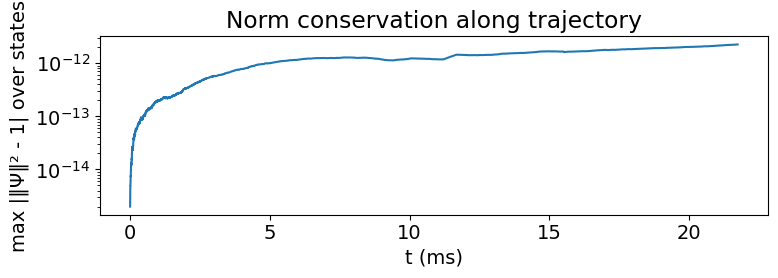

In [ ]:
# Norm conservation diagnostic
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(res.t_grid * 1e3, np.max(np.abs(res.norm_trace - 1.0), axis=1))
ax.set_yscale("log")
ax.set_ylabel("max |‖Ψ‖² - 1| over states")
ax.set_xlabel("t (ms)")
ax.set_title("Norm conservation along trajectory")
plt.tight_layout()
plt.show()

## 5. φ₂ scan — Ramsey fringe

Sweep the carrier phase of the second RF pulse from 0 to 2π. Expect a fringe in the weighted survival, plus visible leakage in/out of the J=1 manifold during the scan.

In [ ]:
phi2_values = np.linspace(0, 2 * np.pi, 16, endpoint=False)
spec = ScanSpec(axis="phi2", values=phi2_values)
t0 = time.perf_counter()
scan = run_scan(cfg, spec, progress=False)
print(f"φ₂ scan ({len(phi2_values)} points): {time.perf_counter() - t0:.1f} s")

φ₂ scan (16 points): 576.3 s


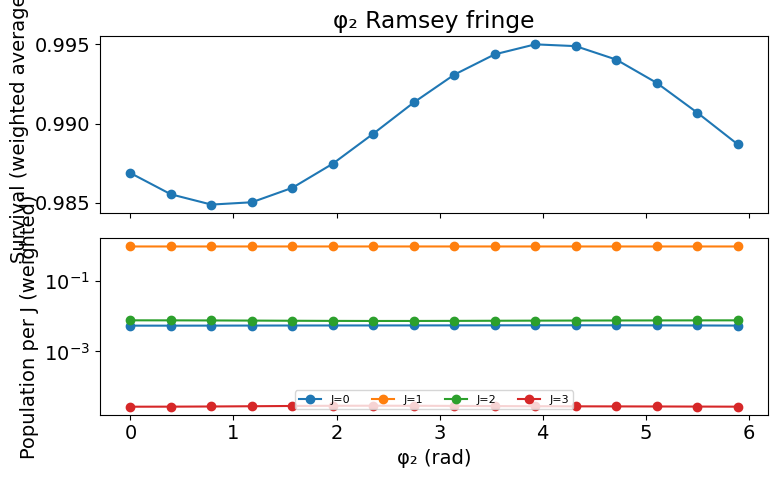

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
axes[0].plot(phi2_values, scan.survival_weighted, "o-")
axes[0].set_ylabel("Survival (weighted average)")
axes[0].set_title("φ₂ Ramsey fringe")
for j_col, J in enumerate(scan.J_values):
    axes[1].plot(phi2_values, scan.per_j_weighted[:, j_col], "o-", label=f"J={J}")
axes[1].set_ylabel("Population per J (weighted)")
axes[1].set_xlabel("φ₂ (rad)")
axes[1].set_yscale("log")
axes[1].legend(loc="best", ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

## 6. Other scan examples (each is one cell — uncomment to run)

All scans use the same `RamseyRFConfig` baseline; the helper deep-copies the config per point and mutates the named knob.

In [ ]:
# # ω_rf detuning scan (±5 kHz around 120 kHz). Fringe spacing ≈ 1/T_separation
# # where T_separation ≈ 2.5 m / V_Z ≈ 13.6 ms ⇒ ~73 Hz expected.
# omega_values = OMEGA_RF + 2*np.pi * np.linspace(-500, 500, 11)
# scan_omega = run_scan(cfg, ScanSpec(axis='omega_rf', values=omega_values), progress=True)
# plt.plot((omega_values - OMEGA_RF) / (2*np.pi), scan_omega.survival_weighted, 'o-')
# plt.xlabel('ω_rf - ω_0 (Hz)'); plt.ylabel('Survival'); plt.show()

In [ ]:
# # Velocity scan (150–220 m/s)
# v_values = np.linspace(150, 220, 8)
# scan_v = run_scan(cfg, ScanSpec(axis='velocity', values=v_values), progress=True)
# plt.plot(v_values, scan_v.survival_weighted, 'o-')
# plt.xlabel('v_z (m/s)'); plt.ylabel('Survival'); plt.show()

In [ ]:
# # rf_amp_1 nutation curve (0 → 2× nominal). With rf_amp_2 = 1, this is a
# # convolution of the nutation in coil 1 with the second pi/2 in coil 2.
# amp_values = np.linspace(0.0, 2.0, 11)
# scan_a1 = run_scan(cfg, ScanSpec(axis='rf_amp_1', values=amp_values), progress=True)
# plt.plot(amp_values, scan_a1.survival_weighted, 'o-')
# plt.xlabel('rf_amp_1 / nominal'); plt.ylabel('Survival'); plt.show()
#
# # Same for coil 2 — rf_amp_2 is fully independent.
# scan_a2 = run_scan(cfg, ScanSpec(axis='rf_amp_2', values=amp_values), progress=True)
# plt.plot(amp_values, scan_a2.survival_weighted, 'o-')
# plt.xlabel('rf_amp_2 / nominal'); plt.ylabel('Survival'); plt.show()

## 7. Convergence (slow — uncomment to run)

These cells re-run a single trajectory at higher Jmax / smaller dt to bound the truncation and time-step errors.

In [ ]:
# # Jmax convergence at the φ₂ = 0 point (single trajectory each).
# # Jmax=4 (basis 100): ~3 min. Jmax=5 (basis 144): ~7 min. Jmax=6 (basis 196): ~30 min.
# from dataclasses import replace
# results = {}
# for Jmax in (3, 4):  # add 5, 6 if you have the patience
#     cfg_J = replace(cfg, Jmax=Jmax)
#     t0 = time.perf_counter()
#     r = RamseyRFSimulator(cfg_J).run()
#     print(f'Jmax={Jmax}: survival={r.survival_weighted:.6f} '
#           f'({time.perf_counter()-t0:.1f} s)')
#     results[Jmax] = r

In [ ]:
# # dt convergence (~30s + 60s + 120s)
# from dataclasses import replace
# for dt in (2e-6, 1e-6, 0.5e-6):
#     cfg_dt = replace(cfg, dt=dt)
#     t0 = time.perf_counter()
#     r = RamseyRFSimulator(cfg_dt).run()
#     print(f'dt={dt*1e6:.2f} us: survival={r.survival_weighted:.6f} '
#           f'({time.perf_counter()-t0:.1f} s)')

## 8. Notes

- `RamseyRFConfig.dt = 2 µs` puts ~4 samples per RF carrier period (8.33 µs). For production runs, halve dt and verify survival differs by < 1e-3 (see dt convergence cell).
- The library does not call `centrex_tlf` rotating-frame / RWA machinery: H is built once per timestep from `generate_uncoupled_hamiltonian_X_function(QN)(E_dc + E_rf(t), 0)` (rad/s) and propagated via `exp(-i H_mid dt)`.
- The Stark sub-matrices `HSx, HSy, HSz` ARE the molecular dipole-coupling operators, so adding `E_rf(t)` to `E_dc` is exactly equivalent to introducing a dipole-coupled time-dependent perturbation — no separate RF operator construction.
- All physics numbers (geometry, fields, frequencies, amplitudes, velocity) live in this notebook only. Nothing under `ramsey_rf/` carries demo defaults.